In [25]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
torch.manual_seed(42)

# ----------------------------------------------------------
# Physics
# ----------------------------------------------------------

k = 1.0                     # Spring constant
tmax = 10.0

# ----------------------------------------------------------
# Neural network representing x(t)
# ----------------------------------------------------------

class SpringNet(nn.Module):

    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 1)
        )

    def forward(self, t):
        return self.net(t)


model = SpringNet()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# ----------------------------------------------------------
# Training points
# ----------------------------------------------------------

t = torch.linspace(0, tmax, 200).view(-1,1)
t.requires_grad_(True)

# ----------------------------------------------------------
# Training
# ----------------------------------------------------------

epochs = 5000
loss_history = []

for epoch in range(epochs):
    optimizer.zero_grad()
    x = model(t)

    # First derivative
    dx = torch.autograd.grad(
        x,
        t,
        grad_outputs=torch.ones_like(x),
        create_graph=True
    )[0]

    # Second derivative
    d2x = torch.autograd.grad(
        dx,
        t,
        grad_outputs=torch.ones_like(dx),
        create_graph=True
    )[0]

    # ---------------------------------------
    # Physics residual: This is where the differential equation is enforced
    #
    # x'' + kx + 0.2x' = 0
    # ---------------------------------------

    residual = d2x + k*x #+ 0.05*dx # 0.2 is the damping coefficient
    # residual = d2x + k*x
    # residual = d2x + torch.sin(x) # Pendulum, g/L = 1
    # duffing oscillator, delta = 0.2, alpha = -1, beta = 1
    # residual = d2x + 0.2*dx - x + x**3
    # Van der Pol oscillator, mu = 1
    # residual = d2x - (1-x**2)*dx + x

    physics_loss = torch.mean(residual**2)

    # ---------------------------------------
    # Initial conditions: This is where the initial conditions are enforced, otherwise x = 0 and x' = 0 at t=0 could be valid solutions, but utterly uninteresting.
    # x(0)=1
    # x'(0)=0
    # ---------------------------------------

    t0 = torch.tensor([[0.0]], requires_grad=True)
    x0 = model(t0)

    dx0 = torch.autograd.grad(
        x0,
        t0,
        grad_outputs=torch.ones_like(x0),
        create_graph=True
    )[0]

    ic_loss = (x0 - 1.0)**2 + dx0**2

    # ---------------------------------------
    # Total loss
    # ---------------------------------------

    loss = physics_loss + ic_loss
    loss.backward()
    optimizer.step()
    loss_history.append(loss.item())

    if epoch % 500 == 0:
        print(
            f"Epoch {epoch:4d} "
            f"Loss = {loss.item():.6e}"
        )

# ----------------------------------------------------------
# Evaluate
# ----------------------------------------------------------

with torch.no_grad():
    x_pred = model(t).squeeze()
x_true = torch.cos(t.squeeze())



Epoch    0 Loss = 1.121006e+00
Epoch  500 Loss = 2.758864e-02
Epoch 1000 Loss = 1.954160e-02
Epoch 1500 Loss = 1.838815e-02
Epoch 2000 Loss = 1.777925e-02
Epoch 2500 Loss = 1.618995e-02
Epoch 3000 Loss = 8.908796e-03
Epoch 3500 Loss = 2.399661e-04
Epoch 4000 Loss = 2.353417e-04
Epoch 4500 Loss = 8.800786e-05


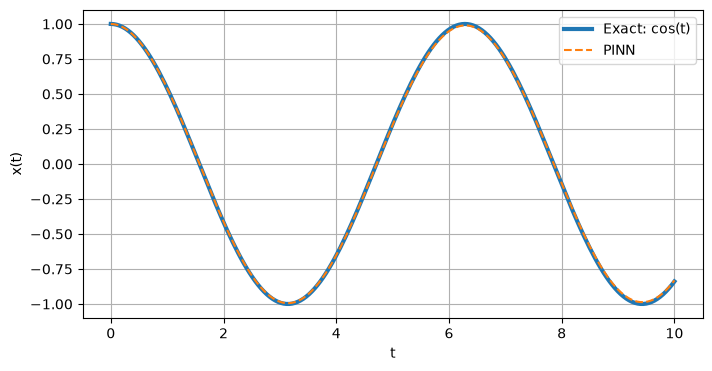

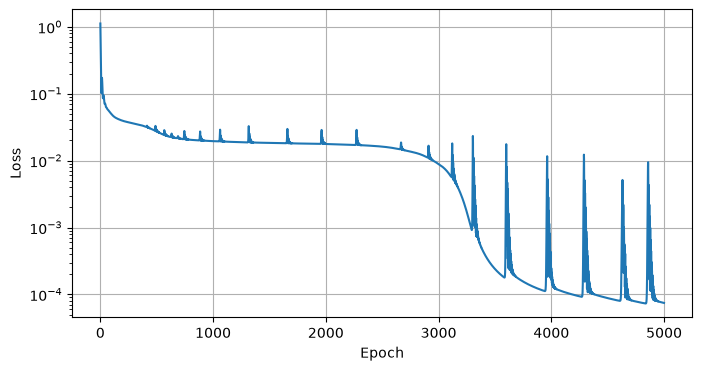

In [26]:
# ----------------------------------------------------------
# Plot solution
# ----------------------------------------------------------

plt.figure(figsize=(8,4))
plt.plot(
    t.detach().numpy(),
    x_true.detach().numpy(),
    label="Exact: cos(t)",
    linewidth=3
)

plt.plot(
    t.detach().numpy(),
    x_pred.detach().numpy(),
    "--",
    label="PINN"
)

plt.xlabel("t")
plt.ylabel("x(t)")
plt.legend()
plt.grid(True)
plt.show()

# ----------------------------------------------------------
# Plot loss
# ----------------------------------------------------------

plt.figure(figsize=(8,4))
plt.semilogy(loss_history)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)

plt.show()

# Physics-Informed Neural Networks (PINNs): An Introduction Using PyTorch Autograd

## Motivation

Most introductions to neural networks present them as function approximators trained using labeled data.

```text
Input
   ↓
Neural Network
   ↓
Prediction
   ↓
Ground Truth
   ↓
Loss
```

However, this is only one application of automatic differentiation.

PyTorch's `autograd` is a **general-purpose automatic differentiation engine**. Once this is understood, it becomes clear that neural networks can be used to solve optimization problems far beyond classification and regression, including:

* Ordinary Differential Equations (ODEs)
* Partial Differential Equations (PDEs)
* Inverse Problems
* Optimal Control
* Scientific Computing

The central idea behind a **Physics-Informed Neural Network (PINN)** is remarkably simple:

> Instead of training the network to match labeled data, train it so that its output satisfies the governing equations of physics.

---

# The Spring-Mass System

Consider the simple harmonic oscillator

$m\ddot{x}+kx=0.$

For simplicity, let

$m=1.$

Then

$
\boxed{\ddot{x}+kx=0.}
$

Suppose the initial conditions are

$
x(0)=1,\qquad
\dot{x}(0)=0.
$

The analytical solution is

$
x(t)=\cos(\sqrt{k},t).
$

Assume, however, that we do **not** know this solution.

---

# Representing the Unknown Function

Instead of approximating data, we approximate the unknown function itself.

We define a neural network

$
x_\theta(t),
$

where

* (t) is the input (time),
* (\theta) represents all trainable weights.

The network therefore represents an entire family of candidate trajectories.

```
time
  │
  ▼
Neural Network
  │
  ▼
x(t)
```

Training consists of finding the parameters (\theta) that produce a function satisfying the differential equation.

---

# Why `requires_grad=True`?

We first create a collection of time samples.

```python
t = torch.linspace(0, 10, 200).view(-1,1)
t.requires_grad_(True)
```

These are **not training labels**.

They are simply points in time where we ask

> "What does the network predict here?"

The important line is

```python
t.requires_grad_(True)
```

Normally, PyTorch computes gradients with respect to network parameters.

Here we also need derivatives with respect to the **input variable** (t).

Setting

```python
requires_grad=True
```

tells PyTorch

> Treat time as a differentiable variable.

Mathematically,

$
x=x(t,\theta),
$

where the output depends on both

* the independent variable (t),
* the trainable parameters (\theta).

Autograd can differentiate with respect to either.

---

# Computing Derivatives

Once the network predicts

```python
x = model(t)
```

we can compute

$
\frac{dx}{dt}
$

using

```python
dx = torch.autograd.grad(
    x,
    t,
    grad_outputs=torch.ones_like(x),
    create_graph=True
)[0]
```

The second derivative is obtained in exactly the same way.

```python
d2x = torch.autograd.grad(
    dx,
    t,
    grad_outputs=torch.ones_like(dx),
    create_graph=True
)[0]
```

Notice that we are **explicitly differentiating with respect to time**, not with respect to the network weights.

At this stage, PyTorch is acting purely as a calculus engine.

---

# Why `create_graph=True`?

This argument is essential.

Normally,

```python
dx = autograd.grad(...)
```

would simply return a tensor containing the derivative.

Instead,

```python
create_graph=True
```

tells PyTorch

> Record how this derivative was computed.

Consequently,

$
\frac{dx}{dt}
$

and

$
\frac{d^2x}{dt^2}
$

remain connected to the computational graph.

This allows gradients to flow through the derivatives during optimization.

Without this option,

Physics-Informed Neural Networks would not work.

---

# Constructing the Physics Residual

The governing equation is

$
\ddot{x}+kx=0.
$

We therefore construct the residual

```python
residual = d2x + k*x
```

If the network exactly satisfies the differential equation,

```text
residual = 0
```

for every time point.

The corresponding loss is

```python
physics_loss = torch.mean(residual**2)
```

Notice that **no labeled data appear anywhere**.

The laws of physics themselves define the loss function.

---

# Initial Conditions

The trivial solution

$
x(t)=0
$

also satisfies the differential equation.

To select the desired trajectory, we enforce the initial conditions.

```python
t0 = torch.tensor([[0.0]], requires_grad=True)

x0 = model(t0)

dx0 = torch.autograd.grad(
    x0,
    t0,
    grad_outputs=torch.ones_like(x0),
    create_graph=True
)[0]
```

The corresponding loss becomes

```python
ic_loss = (x0-1)**2 + dx0**2
```

The total loss is

```python
loss = physics_loss + ic_loss
```

---

# Two Completely Different Uses of Autograd

This is perhaps the most important conceptual point.

Autograd is used twice.

### First

It computes derivatives with respect to **time**.

$
\frac{\partial x}{\partial t},\qquad
\frac{\partial^2x}{\partial t^2}.
$

This constructs the differential equation residual.

---

### Second

After the loss has been built,

```python
loss.backward()
```

computes

$
\frac{\partial L}{\partial\theta},
$

allowing the optimizer to update the network weights.

Thus the same automatic differentiation engine serves two completely different purposes:

1. Calculus
2. Optimization

---

# Computational Graph

The complete graph looks like

```text
              θ (weights)
                  │
                  ▼
          Neural Network
                  │
                  ▼
                x(t)
               /    \
              /      \
             ▼        ▼
          dx/dt      kx
             │
             ▼
         d²x/dt²
             │
             └──────┐
                    ▼
               Residual
                    │
                    ▼
                  Loss
                    │
                    ▼
          loss.backward()
                    │
                    ▼
          ∂Loss / ∂Weights
```

Notice that the optimizer never updates time.

Only the network weights are trainable.

---

# Mathematical View

The network represents

$
x_\theta(t).
$

The residual is
$
\frac{\partial^2x_\theta}{\partial t^2}
+
kx_\theta(t).
$

The loss becomes
$
\frac{1}{N}
\sum_i
r(t_i,\theta)^2.
$

Optimization searches the parameter space until

$
r(t,\theta)\approx0
$

for every sampled time point.

---

# Adding Damping

Suppose the system is now

$
\ddot{x} + c\dot{x} + kx = 0.
$

Nothing changes except the residual.

```python
c = 0.2

residual = d2x + c*dx + k*x
```

Everything else remains identical.

The optimizer is now searching for a function satisfying the damped oscillator equation.

---

# Beyond the Harmonic Oscillator

Exactly the same framework can solve many nonlinear systems.

## Pendulum

$
\ddot{\theta} + \frac{g}{L}\sin\theta = 0
$

```python
residual = d2theta + (g/L)*torch.sin(theta)
```

---

## Duffing Oscillator

$
\ddot{x} + \delta\dot{x} + \alpha x + \beta x^3 = 0
$

```python
residual = (
    d2x
    + delta*dx
    + alpha*x
    + beta*x**3
)
```

---

## Van der Pol Oscillator

$
\ddot{x} - \mu(1-x^2)\dot{x} + x = 0
$

```python
residual = (
    d2x
    - mu*(1-x**2)*dx
    + x
)
```

---

## Systems of ODEs

The Lorenz equations,

$
\dot{x}=\sigma(y-x),
$

$
\dot{y}=x(\rho-z)-y,
$

$
\dot{z}=xy-\beta z,
$

can be handled by letting the network output three functions,

$
x(t),\quad y(t),\quad z(t),
$

and constructing three residuals.

---

# The Bigger Picture

Traditional supervised learning minimizes

$
L(y,\hat y).
$

Physics-Informed Neural Networks minimize

$
L(\text{Differential Equation Residual}).
$

The neural network itself is merely a flexible parameterization of an unknown function.

The true innovation is not the neural network—it is the ability of automatic differentiation to compute exact derivatives of arbitrarily complex computational graphs.

This shifts the role of machine learning from fitting data to solving mathematical and physical constraints.

---

# Key Takeaways

* PyTorch's `autograd` is a general automatic differentiation engine.
* Neural networks can represent unknown functions, not just classifiers.
* `requires_grad=True` on the input variable enables differentiation with respect to that variable.
* `create_graph=True` allows differentiation through derivatives, enabling higher-order optimization.
* PINNs construct a loss from the governing equations rather than labeled data.
* The same autograd engine first computes physical derivatives with respect to the independent variables and then computes parameter gradients with respect to the network weights.
* Changing the physics usually requires changing only the residual equation; the optimization procedure remains identical.

The central conceptual shift is to stop viewing a neural network as a classifier or regressor and instead view it as a **parameterized function**. Training then becomes a search over the space of functions for one that satisfies the desired mathematical constraints.
